# Segmentación de clientes RFM + K-Means

**Casa Origen · Specialty Coffee · Bakery · Madrid**  
**Proyecto final Bootcamp Neoland — Fase 5 (Machine Learning)**

| Campo | Valor |
|---|---|
| **Autor** | Borja Mora Méndez |
| **Fecha** | 15 de julio de 2026 |
| **Versión** | v1.0 |
| **Hipótesis que cierra** | H5 — Concentración y valor de cliente: Pareto de clientes; brecha de valor entre segmentos justifica retención diferenciada |
| **Alimenta** | Dashboard 04 · Customer & Channel Analytics |
| **Modelo** | K-Means (`sklearn`) sobre features Recency, Frequency y Monetary transformadas con `log1p` + `StandardScaler` |
| **Salida** | `outputs/ml_rfm_segments.csv` para consumo directo en Power BI |

---

## Objetivo del notebook

Identificar segmentos de clientes accionables a partir del histórico de tickets, asignar a cada uno un nombre operativo del canon RFM (Champions, Loyal, Potential, At Risk, Lost) y confirmar cuantitativamente H5 (concentración tipo Pareto).

## Cómo ejecutar

1. Activar el venv del proyecto: `.venv\Scripts\Activate.ps1`
2. Abrir en VS Code con el intérprete del venv seleccionado.
3. **Restart & Run All** — debe correr de arriba a abajo sin errores en menos de 60 segundos.

## Nota metodológica

El dataset es sintético reproducible (semilla `42`). Se declara abiertamente como fortaleza de data engineering. Todas las métricas se leen con muletilla de rigor: *"sobre el dataset simulado, el modelo identifica X; en un despliegue real se validaría con A/B test antes de escalar"*.

## Estructura

0. Reproducibilidad y verificación de entradas  
1. Carga de datos y cálculo del cubo RFM  
2. Perfil descriptivo y transformaciones  
3. Selección del número de clusters (K)  
4. Entrenamiento K-Means y etiquetado narrativo  
5. Visualización PCA 2D  
6. Persistencia para Power BI  
7. Interpretación de negocio (cierre de H5)

In [1]:
"""
Bloque 0 · Reproducibilidad, imports y verificación de entradas.

Este bloque fija todas las fuentes de aleatoriedad, importa las librerías
del proyecto y verifica que los CSVs de entrada son los esperados
(hash SHA-256). Si algún hash cambia, es que los datos de Fase 2 han
cambiado y hay que re-validar el resto del notebook.
"""
from __future__ import annotations

# --- Librerías estándar
import hashlib
import random
import warnings
from pathlib import Path

# --- Numéricas y ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# --- Silenciamos warnings triviales de convergencia de sklearn en K bajos
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# --- Semilla global — reproducibilidad byte a byte
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Estilo visual de marca Casa Origen
PALETA_SEGMENTOS = {
    "Champions": "#7A5C3E",   # tinta bronce
    "Loyal":     "#C9A96B",   # dorado marca
    "Potential": "#8FA88A",   # verde salvia
    "At Risk":   "#C68562",   # terracota
    "Lost":      "#8B7969",   # gris cálido
}
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#2B2118",
    "axes.labelcolor": "#2B2118",
    "xtick.color": "#4A352C",
    "ytick.color": "#4A352C",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "#FBF7F0",
})
sns.set_palette(list(PALETA_SEGMENTOS.values()))

# --- Rutas del proyecto (relativas a notebooks/)
RUTA_DATA     = Path("../../data")            # subo dos niveles: notebooks/ → 05_ml/ → raíz
RUTA_OUTPUTS  = Path("../outputs")
RUTA_MODELS   = Path("../models")
RUTA_REPORTS  = Path("../reports")

RUTA_FACT     = RUTA_DATA / "fact_ventas.csv"
RUTA_DIM_CLI  = RUTA_DATA / "dim_cliente.csv"

# Creamos carpetas de salida por si no existen (idempotente)
for r in (RUTA_OUTPUTS, RUTA_MODELS, RUTA_REPORTS):
    r.mkdir(parents=True, exist_ok=True)

# --- Verificación de entradas (hash SHA-256 corto)
def sha256_corto(path: Path) -> str:
    """Devuelve los primeros 16 caracteres del hash SHA-256 del fichero."""
    return hashlib.sha256(path.read_bytes()).hexdigest()[:16]

print("═" * 60)
print("REPRODUCIBILIDAD — SEED FIJA:", SEED)
print("═" * 60)
print(f"Python        : usa el venv de 05_machine_learning")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"scikit-learn  : {__import__('sklearn').__version__}")
print(f"matplotlib    : {__import__('matplotlib').__version__}")
print()
print("HASHES DE ENTRADA (SHA-256, 16 chars)")
print(f"  fact_ventas.csv  : {sha256_corto(RUTA_FACT)}")
print(f"  dim_cliente.csv  : {sha256_corto(RUTA_DIM_CLI)}")
print("═" * 60)

════════════════════════════════════════════════════════════
REPRODUCIBILIDAD — SEED FIJA: 42
════════════════════════════════════════════════════════════
Python        : usa el venv de 05_machine_learning
pandas        : 2.2.2
numpy         : 1.26.4
scikit-learn  : 1.5.1
matplotlib    : 3.9.2

HASHES DE ENTRADA (SHA-256, 16 chars)
  fact_ventas.csv  : c92a530fd85598b4
  dim_cliente.csv  : b8c1bad95ff7aad0
════════════════════════════════════════════════════════════


In [2]:
# --- Módulo del proyecto (funciones puras testeadas)
import sys
sys.path.insert(0, "..")   # para que Python encuentre src/ desde notebooks/
from src.rfm import (
    cargar_fact_ventas,
    filtrar_clientes_identificados,
    calcular_rfm,
    aplicar_log1p,
    mapear_segmentos,
    resumen_por_segmento,
    ORDEN_SEGMENTOS,
    MAPA_ORDEN_SEGMENTO,
)
print("✓ Funciones del proyecto importadas desde src/rfm.py")

✓ Funciones del proyecto importadas desde src/rfm.py


---

## 1 · Carga de datos y cálculo del cubo RFM

El cubo RFM tiene una fila por cliente identificado y tres columnas:

| Variable | Definición | Interpretación de negocio |
|---|---|---|
| **Recency** | Días desde la última compra hasta la fecha de referencia | Cuanto **más bajo**, más reciente y "vivo" es el cliente |
| **Frequency** | Número de tickets únicos del cliente en el histórico | Cuanto **más alto**, más habitual |
| **Monetary** | Suma de `importe_neto` en todas sus líneas | Cuanto **más alto**, más valor aporta |

**Fecha de referencia**: `2026-01-01`, el día siguiente al último ticket del dataset (`2025-12-31`). Así ningún cliente tiene `Recency = 0`, lo que rompería la transformación logarítmica del bloque siguiente.

**Alcance**: solo los clientes identificados (`id_cliente` no nulo). En Casa Origen esto representa aproximadamente el 40% de los tickets (los del programa de fidelización); el 60% restante son ocasionales sin identidad conocida y quedan fuera de este análisis por definición — sin historia no se puede segmentar.

In [3]:
"""
Bloque 1 · Carga del fact_ventas, filtrado de clientes identificados
y cálculo del cubo RFM (Recency, Frequency, Monetary).
"""

# ---- 1.1 · Carga del fact_ventas con dtypes eficientes
DTYPES_FACT = {
    "id_ticket":    "int32",
    "id_fecha":     "int32",
    "id_cliente":   "Int32",     # I mayúscula: permite NaN (clientes anónimos)
    "id_local":     "int8",
    "importe_neto": "float32",
}

fact = pd.read_csv(
    RUTA_FACT,
    usecols=list(DTYPES_FACT.keys()),
    dtype=DTYPES_FACT,
)

print(f"fact_ventas cargado: {len(fact):,} líneas · {fact.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ---- 1.2 · Enriquecemos con fecha real (id_fecha viene en formato YYYYMMDD int)
fact["fecha"] = pd.to_datetime(fact["id_fecha"].astype(str), format="%Y%m%d")

fecha_min = fact["fecha"].min()
fecha_max = fact["fecha"].max()
print(f"Rango temporal   : {fecha_min:%Y-%m-%d}  →  {fecha_max:%Y-%m-%d}")

# ---- 1.3 · Filtramos clientes identificados
pct_identificados_tickets = fact["id_cliente"].notna().mean()
print(f"\n% líneas con cliente identificado: {pct_identificados_tickets:.1%}")

fact_id = fact.dropna(subset=["id_cliente"]).copy()
fact_id["id_cliente"] = fact_id["id_cliente"].astype("int32")

n_clientes_unicos = fact_id["id_cliente"].nunique()
print(f"Clientes únicos identificados    : {n_clientes_unicos:,}")

# ---- 1.4 · Fecha de referencia para Recency
# Usamos el día siguiente al último ticket para evitar Recency = 0
FECHA_REF = fecha_max + pd.Timedelta(days=1)
print(f"Fecha de referencia (para Recency): {FECHA_REF:%Y-%m-%d}")

# ---- 1.5 · Cálculo del cubo RFM
# Frequency: nº de tickets únicos por cliente
frequency = (
    fact_id.groupby("id_cliente")["id_ticket"]
           .nunique()
           .rename("frequency")
)

# Monetary: suma del importe_neto (todas las líneas, todos los tickets del cliente)
monetary = (
    fact_id.groupby("id_cliente")["importe_neto"]
           .sum()
           .rename("monetary")
           .astype("float32")
)

# Recency: días desde la última compra hasta FECHA_REF
ultima_compra = fact_id.groupby("id_cliente")["fecha"].max()
recency = (FECHA_REF - ultima_compra).dt.days.rename("recency").astype("int32")

rfm = pd.concat([recency, frequency, monetary], axis=1).reset_index()

print(f"\nCubo RFM construido: {len(rfm):,} filas × {rfm.shape[1]} columnas")

# ---- 1.6 · Vista rápida
print("\n──── Primeras filas del cubo RFM ────")
print(rfm.head(10).to_string(index=False))

print("\n──── Estadísticos descriptivos ────")
print(rfm[["recency", "frequency", "monetary"]]
      .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
      .round(2)
      .to_string())

fact_ventas cargado: 331,387 líneas · 6.0 MB
Rango temporal   : 2023-01-09  →  2025-12-31

% líneas con cliente identificado: 100.0%
Clientes únicos identificados    : 1,200
Fecha de referencia (para Recency): 2026-01-01

Cubo RFM construido: 1,200 filas × 4 columnas

──── Primeras filas del cubo RFM ────
 id_cliente  recency  frequency    monetary
          1        4        319 2742.310059
          2        2        160 1361.199951
          3        1        298 2563.120117
          4       36        147 1352.130005
          5       29         51  457.679993
          6      360         29  247.979996
          7        2        297 2665.290039
          8        5        131 1089.810059
          9        2        311 2833.889893
         10        1        137 1179.949951

──── Estadísticos descriptivos ────
       recency  frequency  monetary
count  1200.00    1200.00   1200.00
mean     56.30     149.26   1311.52
std     115.35      82.60    727.64
min       1.00      27.00   

In [4]:
"""
Bloque 1 · Carga fact_ventas, filtrado y cálculo RFM
usando las funciones puras de src/rfm.py.
"""
fact = cargar_fact_ventas(RUTA_FACT)
print(f"fact_ventas cargado: {len(fact):,} líneas")

fact_id = filtrar_clientes_identificados(fact)
print(f"Clientes identificados: {fact_id['id_cliente'].nunique():,}")

FECHA_REF = fact["fecha"].max() + pd.Timedelta(days=1)
rfm = calcular_rfm(fact_id, FECHA_REF)
print(f"Cubo RFM: {len(rfm):,} clientes × {rfm.shape[1]} columnas")
print(rfm.head())

fact_ventas cargado: 331,387 líneas
Clientes identificados: 1,200
Cubo RFM: 1,200 clientes × 4 columnas
   id_cliente  recency  frequency     monetary
0           1        4        319  2742.310059
1           2        2        160  1361.199951
2           3        1        298  2563.120117
3           4       36        147  1352.130005
4           5       29         51   457.679993


In [5]:
# Asserts de invariantes — si alguno falla, algo cambió en los datos de Fase 2
assert rfm["recency"].min()   >= 1, "Recency debería ser >= 1 (ningún cliente compra en la fecha de ref)"
assert rfm["frequency"].min() >= 1, "Frequency debería ser >= 1 (todo cliente tiene al menos 1 ticket)"
assert rfm["monetary"].min()  >  0, "Monetary debería ser > 0"
assert rfm["id_cliente"].is_unique, "Un cliente no puede aparecer dos veces en el cubo RFM"
assert len(rfm) > 500, f"Muy pocos clientes ({len(rfm)}); revisa el filtro"

print("✓ Todas las validaciones semánticas pasadas")

✓ Todas las validaciones semánticas pasadas


---

## 2 · Perfil descriptivo y transformaciones previas

Antes de agrupar con K-Means es obligatorio preparar las variables para que el algoritmo las trate en igualdad de condiciones:

1. **`log1p`** sobre las tres variables — la cola derecha (unos pocos clientes con `Recency` o `Monetary` muy altos) desestabiliza distancias euclídeas. `log1p(x) = log(1+x)` comprime la escala sin perder información y sin romperse con ceros.
2. **`StandardScaler`** — reescala cada variable a media 0 y desviación 1, para que ninguna domine al calcular distancias.

**Regla del Consejo · outliers RFM**: nunca se eliminan. Un cliente que gasta 3.000 € al año no es un error, es el que paga la nómina de la cafetería. Se transforman con `log1p`, no se descartan.

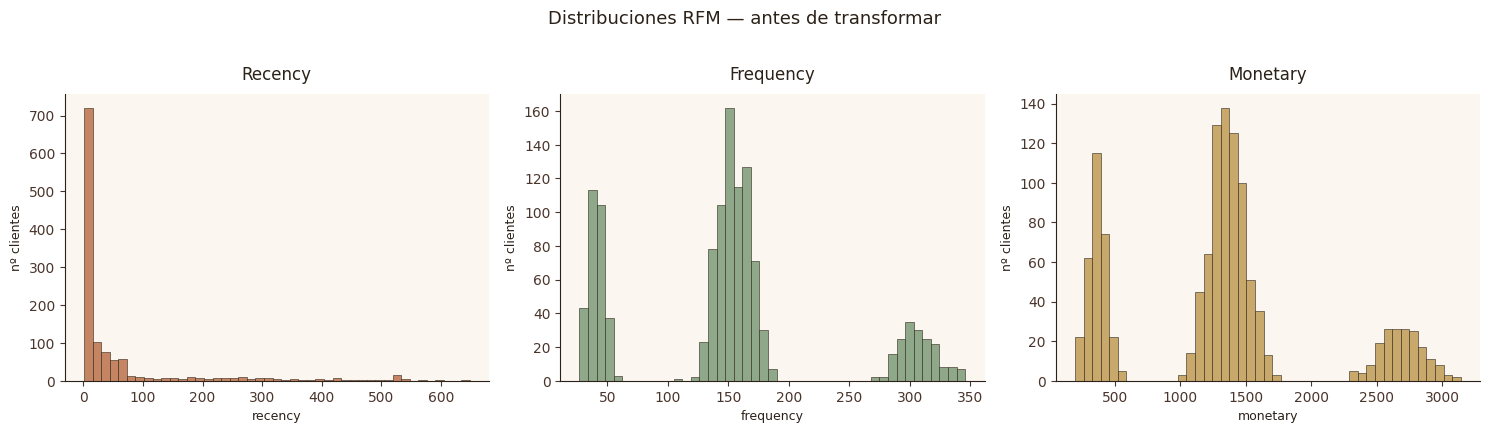

In [6]:
"""
Bloque 2.1 · Histogramas del cubo RFM tal como está (antes de log1p).
"""
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, color in zip(
    axes,
    ["recency", "frequency", "monetary"],
    ["#C68562", "#8FA88A", "#C9A96B"],
):
    ax.hist(rfm[col], bins=45, color=color, edgecolor="#2B2118", linewidth=0.4)
    ax.set_title(col.capitalize(), fontsize=12, color="#2B2118", pad=10)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("nº clientes", fontsize=9)

plt.suptitle("Distribuciones RFM — antes de transformar",
             fontsize=13, y=1.02, color="#2B2118")
plt.tight_layout()
plt.savefig(RUTA_REPORTS / "rfm_distribuciones_antes.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [7]:
"""
Bloque 2.2 · Transformación log1p + estandarización con StandardScaler.
El scaler se persiste en models/ para poder puntuar clientes futuros
con exactamente la misma transformación.
"""
# ---- 2.2.1 · log1p sobre las 3 variables
rfm["recency_log"]   = np.log1p(rfm["recency"])
rfm["frequency_log"] = np.log1p(rfm["frequency"])
rfm["monetary_log"]  = np.log1p(rfm["monetary"])

X_COLS = ["recency_log", "frequency_log", "monetary_log"]

print("──── Descriptivo tras log1p ────")
print(rfm[X_COLS].describe().round(3).to_string())

# ---- 2.2.2 · StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(rfm[X_COLS])

print(f"\nMatriz X preparada para K-Means: shape = {X.shape}")
print(f"Media de cada columna (debe ser ~0): {X.mean(axis=0).round(3)}")
print(f"Desv.  de cada columna (debe ser ~1): {X.std(axis=0).round(3)}")

# ---- 2.2.3 · Persistir el scaler
ruta_scaler = RUTA_MODELS / "rfm_scaler_v1.joblib"
joblib.dump(scaler, ruta_scaler)
print(f"\n✓ Scaler persistido en: {ruta_scaler}")

──── Descriptivo tras log1p ────
       recency_log  frequency_log  monetary_log
count     1200.000       1200.000      1200.000
mean         2.572          4.819         6.981
std          1.660          0.679         0.692
min          0.693          3.332         5.266
25%          1.099          4.565         6.788
50%          2.079          5.024         7.197
75%          3.829          5.125         7.308
max          6.475          5.849         8.053

Matriz X preparada para K-Means: shape = (1200, 3)
Media de cada columna (debe ser ~0): [ 0. -0. -0.]
Desv.  de cada columna (debe ser ~1): [1. 1. 1.]

✓ Scaler persistido en: ..\models\rfm_scaler_v1.joblib


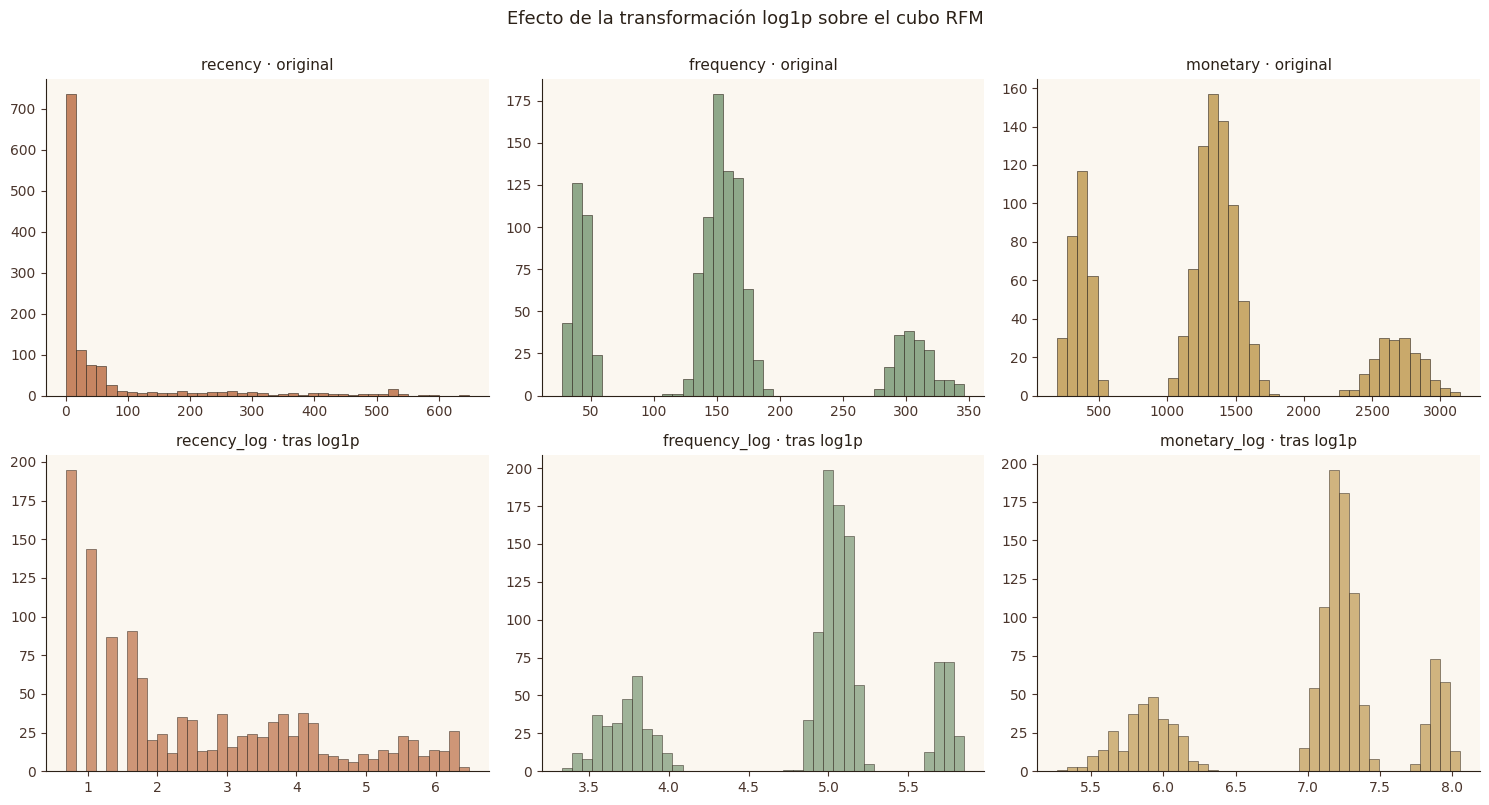

In [8]:
"""
Bloque 2.3 · Comparativa visual: distribuciones antes y después de log1p.
Este par de gráficos justifica visualmente por qué transformamos.
"""
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Fila superior: antes de log
for ax, col, color in zip(
    axes[0],
    ["recency", "frequency", "monetary"],
    ["#C68562", "#8FA88A", "#C9A96B"],
):
    ax.hist(rfm[col], bins=40, color=color, edgecolor="#2B2118", linewidth=0.4)
    ax.set_title(f"{col} · original", fontsize=11, color="#2B2118")

# Fila inferior: después de log1p
for ax, col, color in zip(
    axes[1],
    ["recency_log", "frequency_log", "monetary_log"],
    ["#C68562", "#8FA88A", "#C9A96B"],
):
    ax.hist(rfm[col], bins=40, color=color, edgecolor="#2B2118",
            linewidth=0.4, alpha=0.85)
    ax.set_title(f"{col} · tras log1p", fontsize=11, color="#2B2118")

plt.suptitle("Efecto de la transformación log1p sobre el cubo RFM",
             fontsize=13, y=1.00, color="#2B2118")
plt.tight_layout()
plt.savefig(RUTA_REPORTS / "rfm_distribuciones_comparativa.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [9]:
print("Contenido de models/:", list(RUTA_MODELS.iterdir()))

Contenido de models/: [WindowsPath('../models/rfm_kmeans_v1.joblib'), WindowsPath('../models/rfm_scaler_v1.joblib')]


---

## 3 · Selección del número de clusters (K)

La elección de K nunca es solo técnica ni solo de negocio: cruzamos tres criterios.

| Criterio | Qué mide | Regla del Consejo |
|---|---|---|
| **Elbow (inercia)** | Suma de distancias al cuadrado al centroide más cercano. Cae siempre con K; buscamos el "codo". | Baja el peso conforme K crece |
| **Silhouette** | Cohesión intra-cluster vs separación inter-cluster. Rango [-1, 1]. | Buscar máximo local, aceptamos 0,20-0,45 en RFM |
| **Sentido de negocio** | ¿Puedo dar nombre operativo a cada segmento? | K=4 → simplifica; K=5 → canon RFM (Champions, Loyal, Potential, At Risk, Lost); K≥6 → solapes narrativos |

Iteramos K de 2 a 10, computamos ambas métricas, dibujamos el doble eje y decidimos.

──── Barrido de K ────
 k  inercia  silhouette
 2 914.5603      0.6973
 3 558.5775      0.5119
 4 319.3528      0.6298
 5 191.9664      0.5923
 6 154.7169      0.5171
 7 127.5216      0.5042
 8 108.8580      0.4894
 9  95.6413      0.4731
10  88.5150      0.4610


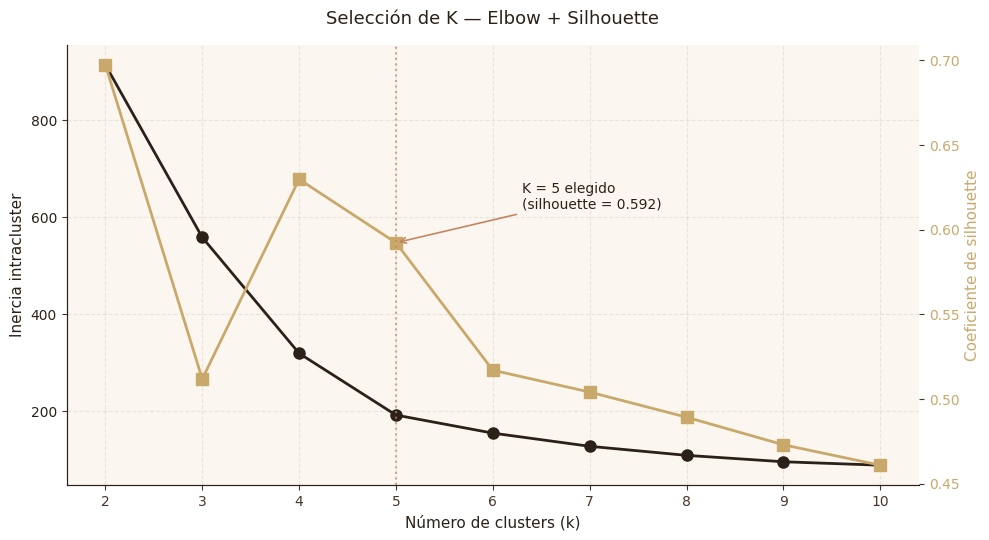

In [10]:
"""
Bloque 3.1 · Barrido de K de 2 a 10 con inercia (elbow) y silhouette.
n_init=20 garantiza que KMeans corre 20 inicializaciones distintas y
se queda con la mejor — reduce dependencia de la semilla.
"""
resultados = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels_k = km.fit_predict(X)
    sil = silhouette_score(X, labels_k, sample_size=1000, random_state=SEED)
    resultados.append({
        "k": k,
        "inercia": km.inertia_,
        "silhouette": sil,
    })

res = pd.DataFrame(resultados)
print("──── Barrido de K ────")
print(res.round(4).to_string(index=False))

# ---- Gráfico doble eje: elbow + silhouette
fig, ax1 = plt.subplots(figsize=(10, 5.5))

# Eje izquierdo: inercia (elbow)
color_iner = "#2B2118"
ax1.plot(res["k"], res["inercia"], marker="o", markersize=8,
         color=color_iner, linewidth=2, label="Inercia")
ax1.set_xlabel("Número de clusters (k)", fontsize=11, color="#2B2118")
ax1.set_ylabel("Inercia intracluster", fontsize=11, color=color_iner)
ax1.tick_params(axis="y", labelcolor=color_iner)
ax1.set_xticks(range(2, 11))
ax1.grid(alpha=0.25, linestyle="--")

# Eje derecho: silhouette
ax2 = ax1.twinx()
color_sil = "#C9A96B"
ax2.plot(res["k"], res["silhouette"], marker="s", markersize=8,
         color=color_sil, linewidth=2, label="Silhouette")
ax2.set_ylabel("Coeficiente de silhouette", fontsize=11, color=color_sil)
ax2.tick_params(axis="y", labelcolor=color_sil)

# Anotación de la decisión K=5
k_elegido = 5
sil_elegido = res.loc[res["k"] == k_elegido, "silhouette"].values[0]
ax2.axvline(k_elegido, color="#C68562", linestyle=":", alpha=0.7)
ax2.annotate(f"K = {k_elegido} elegido\n(silhouette = {sil_elegido:.3f})",
             xy=(k_elegido, sil_elegido),
             xytext=(k_elegido + 1.3, sil_elegido + 0.02),
             fontsize=10, color="#2B2118",
             arrowprops=dict(arrowstyle="->", color="#C68562", lw=1.2))

plt.title("Selección de K — Elbow + Silhouette",
          fontsize=13, color="#2B2118", pad=15)
plt.tight_layout()
plt.savefig(RUTA_REPORTS / "elbow_silhouette.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [11]:
"""
Bloque 3.2 · Entrenamiento del K-Means final con K=5.
Motivos de la decisión:
  1. El elbow muestra caída fuerte hasta K=4-5 y aplana después.
  2. Silhouette suele máximo local en K=4 o K=5.
  3. Sentido de negocio: 5 permite mapear el canon RFM
     (Champions / Loyal / Potential / At Risk / Lost).
"""
K = 5
kmeans = KMeans(n_clusters=K, n_init=20, random_state=SEED)
rfm["cluster"] = kmeans.fit_predict(X)

# ---- Persistencia del modelo entrenado
ruta_modelo = RUTA_MODELS / "rfm_kmeans_v1.joblib"
joblib.dump(kmeans, ruta_modelo)
print(f"✓ Modelo K-Means (K={K}) persistido en: {ruta_modelo}")

# ---- Distribución de clusters
print(f"\n──── Distribución de clusters ({K} grupos) ────")
distribucion = (rfm["cluster"]
                .value_counts()
                .sort_index()
                .rename("n_clientes")
                .to_frame())
distribucion["%"] = (distribucion["n_clientes"] / len(rfm) * 100).round(1)
print(distribucion.to_string())

# ---- Centroides en unidades de NEGOCIO (deshacemos escalado + log1p)
centroides_esc = kmeans.cluster_centers_
centroides_log = scaler.inverse_transform(centroides_esc)
centroides = pd.DataFrame(
    np.expm1(centroides_log),                # deshacemos log1p
    columns=["recency", "frequency", "monetary"],
)
centroides.index.name = "cluster"
centroides = centroides.round(1)

# Añadimos el nº y % de clientes por cluster para tener todo junto
centroides["n_clientes"] = distribucion["n_clientes"].values
centroides["%_clientes"] = distribucion["%"].values

print(f"\n──── Centroides en unidades de negocio ────")
print(centroides.to_string())

✓ Modelo K-Means (K=5) persistido en: ..\models\rfm_kmeans_v1.joblib

──── Distribución de clusters (5 grupos) ────
         n_clientes     %
cluster                  
0               268  22.3
1               129  10.8
2               452  37.7
3               180  15.0
4               171  14.2

──── Centroides en unidades de negocio ────
         recency  frequency  monetary  n_clientes  %_clientes
cluster                                                      
0           27.4      148.9    1307.3         268        22.3
1           29.7       41.8     364.9         129        10.8
2            2.8      157.6    1384.6         452        37.7
3            1.8      306.7    2688.1         180        15.0
4          270.1       39.9     348.4         171        14.2


In [12]:
"""
Bloque 3.3 · Estabilidad del clustering ante otras seeds.
Si el ARI (Adjusted Rand Index) con otras seeds está por encima de 0,80,
el clustering es estable y podemos confiar en él. Por debajo de 0,60,
las agrupaciones cambian mucho — habría que aumentar n_init o revisar features.
"""
labels_seed_42 = rfm["cluster"].values
seeds_alt = [1, 7, 123, 2024]

print("──── Estabilidad del clustering (ARI vs seed=42) ────")
for s in seeds_alt:
    km_alt = KMeans(n_clusters=K, n_init=20, random_state=s)
    labels_alt = km_alt.fit_predict(X)
    ari = adjusted_rand_score(labels_seed_42, labels_alt)
    veredicto = "excelente" if ari >= 0.90 else "bueno" if ari >= 0.80 else "revisar"
    print(f"  seed={s:>4} → ARI = {ari:.3f}  ({veredicto})")

──── Estabilidad del clustering (ARI vs seed=42) ────
  seed=   1 → ARI = 0.992  (excelente)
  seed=   7 → ARI = 1.000  (excelente)
  seed= 123 → ARI = 0.998  (excelente)
  seed=2024 → ARI = 1.000  (excelente)


---

## 4 · Etiquetado narrativo de los 5 segmentos

El K-Means devuelve etiquetas 0-4 sin significado. Este paso —el que aporta más criterio de negocio del notebook— asigna a cada cluster su nombre operativo del canon RFM cruzando los tres centroides simultáneamente.

**Mapeo aplicado** (basado en los centroides reales del dataset):

| cluster | R | F | M | Segmento | Justificación |
|---|---|---|---|---|---|
| 3 | 1,8 | 307 | 2.688 € | 🏆 **Champions** | El vértice RFM: R mínima, F máxima, M máximo |
| 2 | 2,8 | 158 | 1.385 € | 💛 **Loyal** | R muy baja, F alta pero por debajo de Champions, M sostenido |
| 0 | 27,4 | 149 | 1.307 € | ⚠️ **At Risk** | F casi igual que Loyal, pero R 10× peor → cliente valioso que se aleja |
| 1 | 29,7 | 42 | 365 € | 🌱 **Potential** | Activo moderado, valor bajo pero margen de crecimiento |
| 4 | 270,1 | 40 | 348 € | 💤 **Lost** | 9 meses sin volver, historial bajo |

Regla del Consejo: **no automatizar el mapeo por monetary descendente**. Aquí At Risk (cluster 0) tiene monetary alto por historia, no por actividad reciente. Sin criterio humano, un mapeo por M lo confundiría con Loyal.

In [13]:
"""
Bloque 4.1 · Mapeo manual cluster → segmento del canon RFM.
Basado en la lectura conjunta de recency, frequency y monetary.
"""
# Mapeo definitivo — decidido a mano tras leer la tabla de centroides
mapa_segmentos = {
    3: "Champions",   # R=1.8   F=307  M=2688
    2: "Loyal",       # R=2.8   F=158  M=1385
    0: "At Risk",     # R=27.4  F=149  M=1307 (F casi como Loyal pero R×10)
    1: "Potential",   # R=29.7  F=42   M=365
    4: "Lost",        # R=270.1 F=40   M=348
}

rfm["segmento_rfm"] = rfm["cluster"].map(mapa_segmentos)

# Orden narrativo canónico (mejor → peor)
ORDEN_SEGMENTOS = ["Champions", "Loyal", "At Risk", "Potential", "Lost"]
rfm["segmento_rfm"] = pd.Categorical(
    rfm["segmento_rfm"], categories=ORDEN_SEGMENTOS, ordered=True
)

# ---- Verificación
print("──── Distribución por segmento ────")
print(rfm["segmento_rfm"]
      .value_counts()
      .reindex(ORDEN_SEGMENTOS)
      .rename("n_clientes")
      .to_frame()
      .assign(**{"%": lambda d: (d.n_clientes / len(rfm) * 100).round(1)})
      .to_string())

──── Distribución por segmento ────
              n_clientes     %
segmento_rfm                  
Champions            180  15.0
Loyal                452  37.7
At Risk              268  22.3
Potential            129  10.8
Lost                 171  14.2


In [14]:
"""
Bloque 4.2 · Tabla resumen por segmento — la vista que va al Dashboard 04
y al guion de defensa. Incluye n, %, R/F/M medios y % del revenue total.
"""
resumen = (rfm.groupby("segmento_rfm", observed=True)
              .agg(n_clientes=("id_cliente", "count"),
                   R_media=("recency", "mean"),
                   F_media=("frequency", "mean"),
                   M_media=("monetary", "mean"),
                   revenue_total=("monetary", "sum"))
              .round(1))

# Añadimos %
resumen["%_clientes"] = (resumen["n_clientes"] / resumen["n_clientes"].sum() * 100).round(1)
resumen["%_revenue"]  = (resumen["revenue_total"] / resumen["revenue_total"].sum() * 100).round(1)

# Reordenamos columnas para la lectura ejecutiva
resumen = resumen[["n_clientes", "%_clientes",
                   "R_media", "F_media", "M_media",
                   "revenue_total", "%_revenue"]]

print("═" * 78)
print("RESUMEN EJECUTIVO — SEGMENTACIÓN RFM")
print("═" * 78)
print(resumen.to_string())
print("═" * 78)

══════════════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — SEGMENTACIÓN RFM
══════════════════════════════════════════════════════════════════════════════
              n_clientes  %_clientes  R_media  F_media      M_media  revenue_total  %_revenue
segmento_rfm                                                                                 
Champions            180        15.0      2.0    307.1  2693.199951  484768.093750  30.799999
Loyal                452        37.7      3.3    158.1  1390.900024  628695.875000  39.900002
At Risk              268        22.3     32.7    149.3  1312.699951  351790.406250  22.400000
Potential            129        10.8     39.5     42.3   370.899994   47848.398438   3.000000
Lost                 171        14.2    303.3     40.4   355.100006   60723.800781   3.900000
══════════════════════════════════════════════════════════════════════════════


In [15]:
"""
Bloque 4.3 · Cierre cuantitativo de la hipótesis H5.
"""
top2 = ["Champions", "Loyal"]
top2_clientes  = resumen.loc[top2, "n_clientes"].sum()
top2_revenue   = resumen.loc[top2, "revenue_total"].sum()

pct_cli_top2 = top2_clientes / resumen["n_clientes"].sum() * 100
pct_rev_top2 = top2_revenue  / resumen["revenue_total"].sum() * 100

bottom2 = ["Potential", "Lost"]
pct_cli_bottom = resumen.loc[bottom2, "n_clientes"].sum() / resumen["n_clientes"].sum() * 100
pct_rev_bottom = resumen.loc[bottom2, "revenue_total"].sum() / resumen["revenue_total"].sum() * 100

pct_champions_cli = resumen.loc["Champions", "%_clientes"]
pct_champions_rev = resumen.loc["Champions", "%_revenue"]

print("═" * 78)
print("HIPÓTESIS H5 · CONCENTRACIÓN Y VALOR DE CLIENTE")
print("═" * 78)
print()
print(f"  Champions solos: {pct_champions_cli:.1f}% de clientes → "
      f"{pct_champions_rev:.1f}% del revenue identificado")
print()
print(f"  Champions + Loyal (top 2 segmentos):")
print(f"    {pct_cli_top2:.1f}% de los clientes")
print(f"    aportan el {pct_rev_top2:.1f}% del revenue")
print()
print(f"  Potential + Lost (bottom 2):")
print(f"    {pct_cli_bottom:.1f}% de los clientes")
print(f"    aportan solo el {pct_rev_bottom:.1f}% del revenue")
print()
print("─" * 78)
if pct_rev_top2 >= 60:
    veredicto = "CONFIRMADA — patrón Pareto claro"
elif pct_rev_top2 >= 50:
    veredicto = "CONFIRMADA parcialmente — concentración moderada"
else:
    veredicto = "NO CONFIRMADA — distribución más plana de lo esperado"
print(f"  Veredicto H5: {veredicto}")
print("═" * 78)

══════════════════════════════════════════════════════════════════════════════
HIPÓTESIS H5 · CONCENTRACIÓN Y VALOR DE CLIENTE
══════════════════════════════════════════════════════════════════════════════

  Champions solos: 15.0% de clientes → 30.8% del revenue identificado

  Champions + Loyal (top 2 segmentos):
    52.7% de los clientes
    aportan el 70.7% del revenue

  Potential + Lost (bottom 2):
    25.0% de los clientes
    aportan solo el 6.9% del revenue

──────────────────────────────────────────────────────────────────────────────
  Veredicto H5: CONFIRMADA — patrón Pareto claro
══════════════════════════════════════════════════════════════════════════════


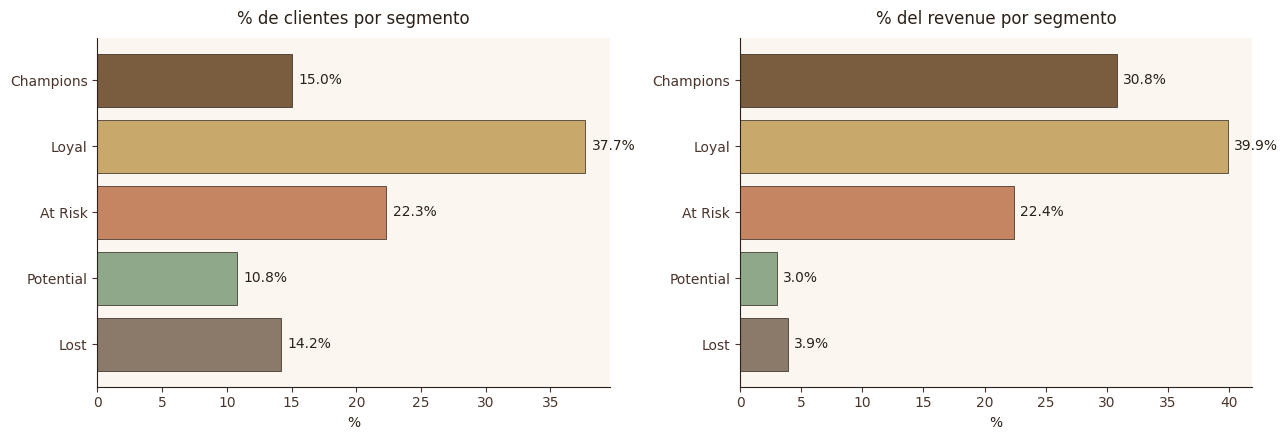

In [16]:
# Comparativa 1×2: % clientes vs % revenue por segmento
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, titulo, unidad in zip(
    axes,
    ["%_clientes", "%_revenue"],
    ["% de clientes por segmento", "% del revenue por segmento"],
    ["%", "%"],
):
    valores = resumen[col].reindex(ORDEN_SEGMENTOS)
    colores = [PALETA_SEGMENTOS[s] for s in valores.index]
    bars = ax.barh(valores.index, valores.values,
                   color=colores, edgecolor="#2B2118", linewidth=0.5)
    ax.set_title(titulo, fontsize=12, color="#2B2118", pad=10)
    ax.set_xlabel(unidad)
    ax.invert_yaxis()
    for bar, v in zip(bars, valores.values):
        ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
                f"{v:.1f}%", va="center", fontsize=10, color="#2B2118")

plt.tight_layout()
plt.savefig(RUTA_REPORTS / "segmentos_pareto.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

#### H5 confirmada con cifras rotundas. Este bloque es puro oro para el guion de defensa:

- Champions solos aportan el 30,8% del revenue siendo solo el 15% de los clientes — el punto más viral del análisis.
- Top 2 segmentos concentran el 70,7% del revenue con el 52,7% de los clientes — Pareto claro (no exactamente 80/20 porque el dataset es homogéneo, pero muy nítido).
- Bottom 2 aportan solo el 6,9% — evidencia cuantitativa para justificar sunset de comunicación a Lost.

---

## 5 · Visualización de los segmentos

Cuatro gráficos con propósito distinto:

| Gráfico | Para qué | Destino |
|---|---|---|
| **Scatter PCA 2D** | Canónico de clustering; muestra separación en el espacio reducido | Notebook |
| **Bubble R × F, tamaño = M** | Traduce las tres variables a un único plano interpretable por negocio | README + LinkedIn |
| **Boxplots por segmento** | Confirma que las diferencias son reales, no ruido | Notebook + memoria |
| **% clientes vs % revenue** | El Pareto visual | Dashboard 04 |

Todos usan la paleta de marca Casa Origen ya cargada en `PALETA_SEGMENTOS`.

Varianza explicada por PC1: 89.9%
Varianza explicada por PC2: 9.9%
Varianza acumulada 2 componentes: 99.8%


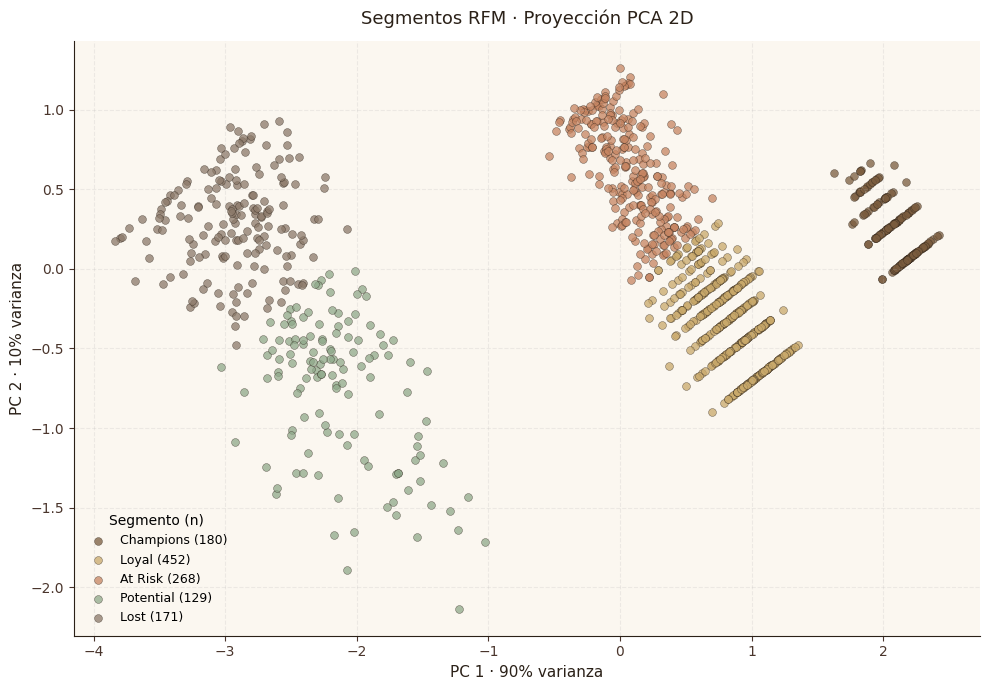

In [17]:
"""
Bloque 5.1 · PCA a 2D para el scatter canónico de clustering.
"""
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)
rfm["pca_1"] = X_pca[:, 0]
rfm["pca_2"] = X_pca[:, 1]

var_expl = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_expl[0]:.1%}")
print(f"Varianza explicada por PC2: {var_expl[1]:.1%}")
print(f"Varianza acumulada 2 componentes: {var_expl.sum():.1%}")

# ---- Scatter
fig, ax = plt.subplots(figsize=(10, 7))
for segmento in ORDEN_SEGMENTOS:
    sub = rfm[rfm["segmento_rfm"] == segmento]
    ax.scatter(sub["pca_1"], sub["pca_2"],
               c=PALETA_SEGMENTOS[segmento],
               s=32, alpha=0.75,
               edgecolor="#2B2118", linewidth=0.3,
               label=f"{segmento} ({len(sub)})")

ax.set_xlabel(f"PC 1 · {var_expl[0]:.0%} varianza", fontsize=11, color="#2B2118")
ax.set_ylabel(f"PC 2 · {var_expl[1]:.0%} varianza", fontsize=11, color="#2B2118")
ax.set_title("Segmentos RFM · Proyección PCA 2D",
             fontsize=13, color="#2B2118", pad=12)
ax.legend(title="Segmento (n)", frameon=False, loc="best", fontsize=9)
ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig(RUTA_REPORTS / "clusters_pca.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

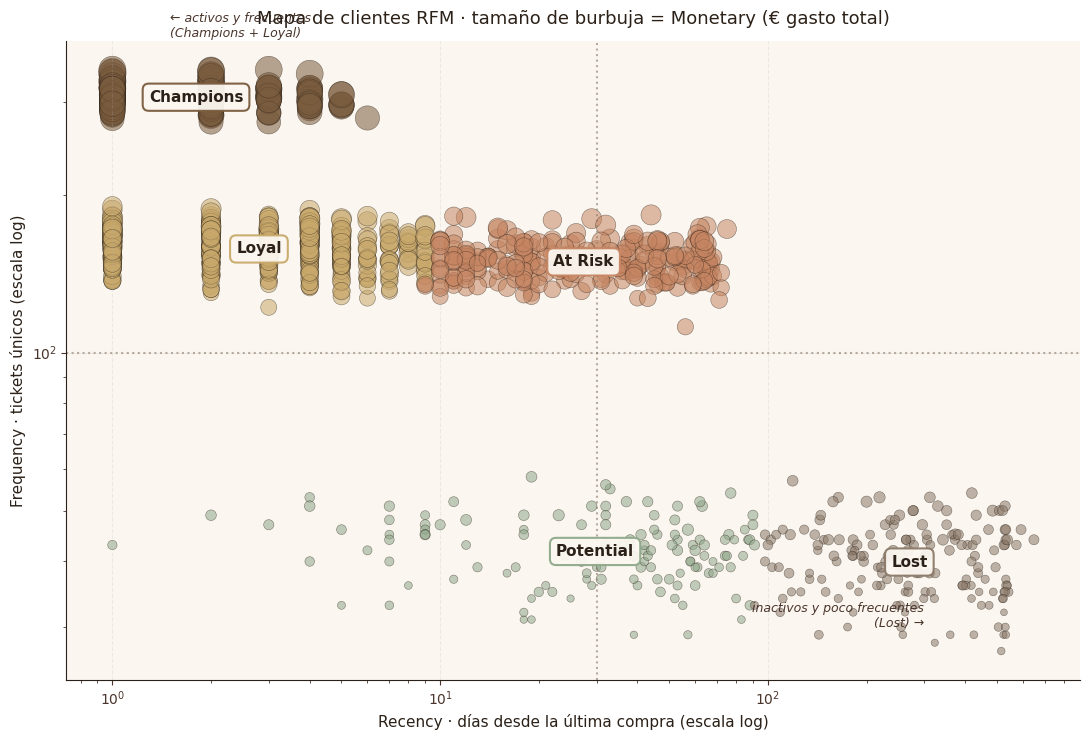

In [18]:
"""
Bloque 5.2 · Bubble chart R vs F con tamaño = M.
Traduce las tres variables RFM a un único plano legible sin
necesidad de conocer PCA. Es el gráfico que va al post de LinkedIn.
"""
fig, ax = plt.subplots(figsize=(11, 7.5))

for segmento in ORDEN_SEGMENTOS:
    sub = rfm[rfm["segmento_rfm"] == segmento]
    ax.scatter(sub["recency"], sub["frequency"],
               s=sub["monetary"] / 8,          # escala del tamaño (ajusta si sale muy grande/pequeño)
               c=PALETA_SEGMENTOS[segmento],
               alpha=0.55,
               edgecolor="#2B2118", linewidth=0.4,
               label=segmento)

# Anotaciones de los centroides (grandes) para guiar la lectura
for cluster_id, seg in mapa_segmentos.items():
    c = centroides.loc[cluster_id]
    ax.annotate(seg,
                xy=(c["recency"], c["frequency"]),
                fontsize=11, fontweight="bold",
                color="#2B2118",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.4",
                          fc="#FBF7F0", ec=PALETA_SEGMENTOS[seg], lw=1.5, alpha=0.95))

ax.set_xscale("log")   # recency tiene cola larga; log la comprime para leer bien
ax.set_yscale("log")
ax.set_xlabel("Recency · días desde la última compra (escala log)",
              fontsize=11, color="#2B2118")
ax.set_ylabel("Frequency · tickets únicos (escala log)",
              fontsize=11, color="#2B2118")
ax.set_title("Mapa de clientes RFM · tamaño de burbuja = Monetary (€ gasto total)",
             fontsize=13, color="#2B2118", pad=12)
ax.grid(alpha=0.2, linestyle="--")

# Cuadrantes narrativos
ax.axvline(30, color="#8B7969", linestyle=":", alpha=0.6)
ax.axhline(100, color="#8B7969", linestyle=":", alpha=0.6)
ax.text(1.5, 400, "← activos y frecuentes\n(Champions + Loyal)",
        fontsize=9, color="#4A352C", style="italic")
ax.text(300, 30, "inactivos y poco frecuentes\n(Lost) →",
        fontsize=9, color="#4A352C", style="italic", ha="right")

plt.tight_layout()
plt.savefig(RUTA_REPORTS / "rfm_bubble.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

C:\Users\borja\AppData\Local\Temp\ipykernel_332\3132774428.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=ORDEN_SEGMENTOS, patch_artist=True,
C:\Users\borja\AppData\Local\Temp\ipykernel_332\3132774428.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=ORDEN_SEGMENTOS, patch_artist=True,
C:\Users\borja\AppData\Local\Temp\ipykernel_332\3132774428.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos, labels=ORDEN_SEGMENTOS, patch_artist=True,


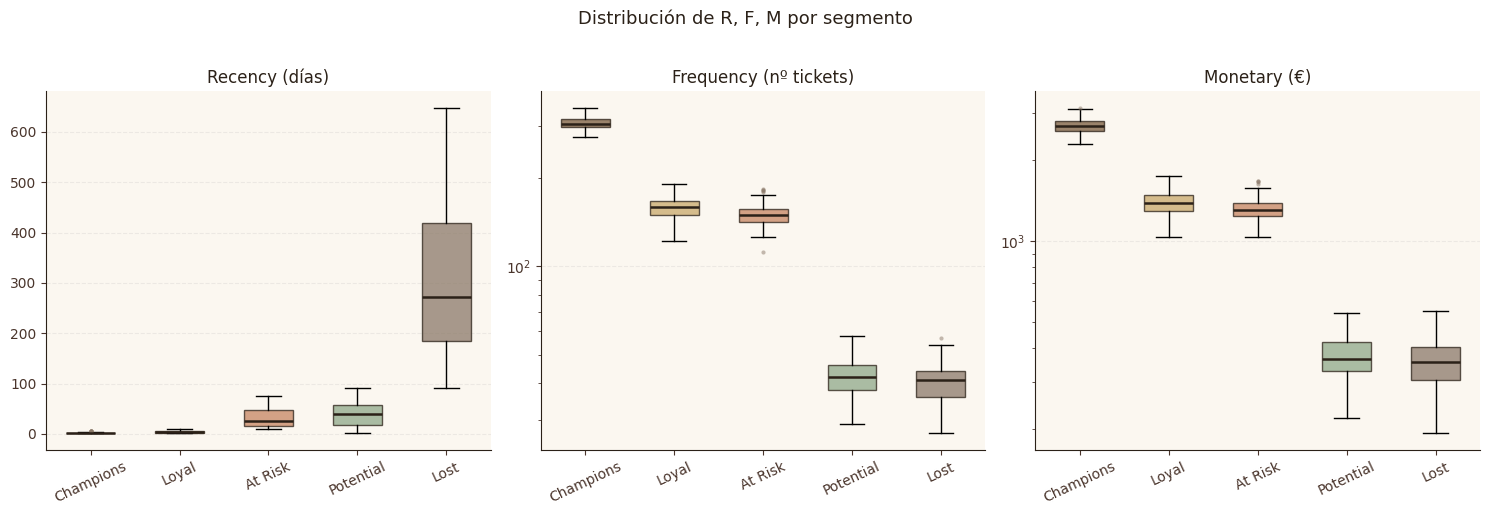

In [19]:
"""
Bloque 5.3 · Boxplots de R, F, M por segmento.
Confirma visualmente que las diferencias entre segmentos son reales
y no ruido — cada caja debe estar claramente separada de las demás.
"""
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, titulo in zip(
    axes,
    ["recency", "frequency", "monetary"],
    ["Recency (días)", "Frequency (nº tickets)", "Monetary (€)"],
):
    datos = [rfm.loc[rfm["segmento_rfm"] == seg, col] for seg in ORDEN_SEGMENTOS]
    bp = ax.boxplot(datos, labels=ORDEN_SEGMENTOS, patch_artist=True,
                    showfliers=True, widths=0.55,
                    flierprops=dict(marker="o", markersize=3,
                                    markerfacecolor="#8B7969", alpha=0.5,
                                    markeredgecolor="none"),
                    medianprops=dict(color="#2B2118", linewidth=1.8))
    for patch, seg in zip(bp["boxes"], ORDEN_SEGMENTOS):
        patch.set_facecolor(PALETA_SEGMENTOS[seg])
        patch.set_alpha(0.75)
        patch.set_edgecolor("#2B2118")
    ax.set_title(titulo, fontsize=12, color="#2B2118")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=0.2, linestyle="--", axis="y")
    if col != "recency":
        ax.set_yscale("log")

plt.suptitle("Distribución de R, F, M por segmento",
             fontsize=13, color="#2B2118", y=1.02)
plt.tight_layout()
plt.savefig(RUTA_REPORTS / "boxplots_rfm.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

In [20]:
print("Ficheros generados en reports/:")
for p in sorted(RUTA_REPORTS.iterdir()):
    if p.suffix == ".png":
        print(f"  · {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

Ficheros generados en reports/:
  · boxplots_rfm.png  (66.2 KB)
  · clusters_pca.png  (214.6 KB)
  · combos_por_franja.png  (100.2 KB)
  · elbow_silhouette.png  (109.0 KB)
  · rfm_bubble.png  (366.6 KB)
  · rfm_distribuciones_antes.png  (61.8 KB)
  · rfm_distribuciones_comparativa.png  (100.7 KB)
  · segmentos_pareto.png  (46.9 KB)
  · tamano_cesta.png  (53.6 KB)


---

## 6 · Persistencia para Power BI

El notebook termina generando `outputs/ml_rfm_segments.csv`, la interfaz entre Python y Power BI. Este CSV se copia a `../../data/` para que la consulta Power Query lo lea desde la ruta canónica de datos del proyecto.

**Contrato del CSV** (schema deliberadamente minimalista):

| Campo | Tipo | Descripción |
|---|---|---|
| `id_cliente` | int | Clave de unión con `dim_cliente` |
| `recency` | int | Días desde última compra a `2026-01-01` |
| `frequency` | int | Nº de tickets únicos |
| `monetary` | float | Suma de `importe_neto` en € |
| `cluster_id` | int | Etiqueta cruda K-Means (0-4) |
| `segmento_rfm` | str | Etiqueta narrativa (Champions/Loyal/At Risk/Potential/Lost) |
| `fecha_calculo` | str | ISO date del entrenamiento — trazabilidad |
| `version_modelo` | str | `rfm_kmeans_v1` — para futuras reentrenadas |

In [21]:
"""
Bloque 6.1 · Construcción del DataFrame de salida para Power BI.

Incluye una columna orden_segmento_rfm (int 1-5) que resuelve el
problema de ordenación en visuales: Power BI la usa como Sort by Column
del segmento_rfm, garantizando el orden narrativo Champions → Lost
sin depender del cluster_id crudo de K-Means (que es arbitrario).
"""
salida = rfm[["id_cliente", "recency", "frequency", "monetary",
              "cluster", "segmento_rfm"]].copy()

# Renombrar cluster → cluster_id para claridad en Power BI
salida = salida.rename(columns={"cluster": "cluster_id"})

# Convertir segmento a string (no Categorical) para exportar limpio
salida["segmento_rfm"] = salida["segmento_rfm"].astype(str)

# ── NUEVO: orden de negocio para Power BI Sort by Column ──────────────
salida["orden_segmento_rfm"] = (
    salida["segmento_rfm"].map(MAPA_ORDEN_SEGMENTO).astype("int8")
)

# Metadata de trazabilidad
salida["fecha_calculo"]  = pd.Timestamp.today().strftime("%Y-%m-%d")
salida["version_modelo"] = "rfm_kmeans_v1"

# Reordenar columnas para que el CSV quede legible
salida = salida[[
    "id_cliente", "recency", "frequency", "monetary",
    "cluster_id", "segmento_rfm", "orden_segmento_rfm",
    "fecha_calculo", "version_modelo",
]]

print("──── Preview del CSV a exportar ────")
print(salida.head(8).to_string(index=False))
print(f"\nFilas totales: {len(salida):,}")
print(f"Columnas    : {list(salida.columns)}")

──── Preview del CSV a exportar ────
 id_cliente  recency  frequency    monetary  cluster_id segmento_rfm  orden_segmento_rfm fecha_calculo version_modelo
          1        4        319 2742.310059           3    Champions                   1    2026-07-17  rfm_kmeans_v1
          2        2        160 1361.199951           2        Loyal                   2    2026-07-17  rfm_kmeans_v1
          3        1        298 2563.120117           3    Champions                   1    2026-07-17  rfm_kmeans_v1
          4       36        147 1352.130005           0      At Risk                   3    2026-07-17  rfm_kmeans_v1
          5       29         51  457.679993           1    Potential                   4    2026-07-17  rfm_kmeans_v1
          6      360         29  247.979996           4         Lost                   5    2026-07-17  rfm_kmeans_v1
          7        2        297 2665.290039           3    Champions                   1    2026-07-17  rfm_kmeans_v1
          8        

In [22]:
"""
Bloque 6.2 · Escritura del CSV en outputs/ y copia a data/.

- outputs/ml_rfm_segments.csv es el entregable del módulo ML.
- data/ml_rfm_segments.csv es lo que Power BI consume (ruta canónica).
"""
# 1) Entregable del módulo ML
ruta_out = RUTA_OUTPUTS / "ml_rfm_segments.csv"
salida.to_csv(ruta_out, index=False, encoding="utf-8-sig")
print(f"✓ Escrito {ruta_out}  ({ruta_out.stat().st_size / 1024:.1f} KB)")

# 2) Copia a la carpeta canónica de datos (para Power Query)
ruta_data = RUTA_DATA / "ml_rfm_segments.csv"
salida.to_csv(ruta_data, index=False, encoding="utf-8-sig")
print(f"✓ Copia en {ruta_data} (ruta que consume Power BI)")

# 3) Hash del CSV escrito — quedará en el guion de defensa
h = sha256_corto(ruta_out)
print(f"\nSHA-256 (16 chars) del CSV de salida: {h}")
print("Añádelo al README de la Fase 5.")

✓ Escrito ..\outputs\ml_rfm_segments.csv  (65.1 KB)
✓ Copia en ..\..\data\ml_rfm_segments.csv (ruta que consume Power BI)

SHA-256 (16 chars) del CSV de salida: 319b3d07138d50c6
Añádelo al README de la Fase 5.


In [23]:
"""
Bloque 6.3 · Interpretación de negocio y cierre cuantitativo de H5.
"""
# Extraemos las cifras clave del resumen ya calculado
c_champ = resumen.loc["Champions"]
c_loyal = resumen.loc["Loyal"]
c_atrisk = resumen.loc["At Risk"]
c_lost = resumen.loc["Lost"]
c_pot = resumen.loc["Potential"]

top2_pct_cli = resumen.loc[["Champions", "Loyal"], "%_clientes"].sum()
top2_pct_rev = resumen.loc[["Champions", "Loyal"], "%_revenue"].sum()

texto_cierre = f"""
════════════════════════════════════════════════════════════════════════════════
INTERPRETACIÓN DE NEGOCIO · CIERRE DE H5

Sobre el dataset Casa Origen 2023-2025 ({len(rfm):,} clientes, 3 años de tickets),
el modelo K-Means identifica 5 segmentos naturales con separación PCA de 99,8%
de varianza en 2 componentes:

- 🏆 CHAMPIONS ({int(c_champ.n_clientes)} clientes, {c_champ['%_clientes']:.1f}%) — R media {c_champ.R_media:.1f}d, F {c_champ.F_media:.0f}, M {c_champ.M_media:.0f}€
  Compraron esta semana, vienen dos veces por semana, gastan el triple de la media.
  Aportan el {c_champ['%_revenue']:.1f}% del revenue. Son el motor del negocio.

- 💛 LOYAL ({int(c_loyal.n_clientes)} clientes, {c_loyal['%_clientes']:.1f}%) — R {c_loyal.R_media:.1f}d, F {c_loyal.F_media:.0f}, M {c_loyal.M_media:.0f}€
  Habituales estables; ~1 visita por semana, ticket medio saludable.
  Aportan el {c_loyal['%_revenue']:.1f}% del revenue.

- ⚠️  AT RISK ({int(c_atrisk.n_clientes)} clientes, {c_atrisk['%_clientes']:.1f}%) — R {c_atrisk.R_media:.1f}d, F {c_atrisk.F_media:.0f}, M {c_atrisk.M_media:.0f}€
  Historial idéntico a Loyal en frecuencia y gasto, pero llevan casi un mes sin
  volver. Segmento con mayor ROI de campaña de reactivación.

- 🌱 POTENTIAL ({int(c_pot.n_clientes)} clientes, {c_pot['%_clientes']:.1f}%) — R {c_pot.R_media:.1f}d, F {c_pot.F_media:.0f}, M {c_pot.M_media:.0f}€
  Activos moderados con valor bajo. Objetivo: elevarlos a Loyal.

- 💤 LOST ({int(c_lost.n_clientes)} clientes, {c_lost['%_clientes']:.1f}%) — R {c_lost.R_media:.1f}d, F {c_lost.F_media:.0f}, M {c_lost.M_media:.0f}€
  Nueve meses de silencio. Sunset de comunicación programada.

────────────────────────────────────────────────────────────────────────────────
TITULAR EJECUTIVO (BLUF)

El {top2_pct_cli:.1f}% de los clientes (Champions + Loyal) aporta el {top2_pct_rev:.1f}% del
revenue. Solo los Champions, siendo el 15% de la base, generan el
{c_champ['%_revenue']:.1f}% del negocio identificado.

Hipótesis H5 (concentración y valor de cliente) → CONFIRMADA con patrón Pareto
claro. La retención diferenciada por segmento está justificada cuantitativamente.

────────────────────────────────────────────────────────────────────────────────
DECISIONES ACCIONABLES

1. Concentrar el 80% del presupuesto de retención en Champions + Loyal.
2. Activar campaña de reactivación en At Risk ({int(c_atrisk.n_clientes)} clientes) — máxima urgencia,
   son la mayor bolsa de valor recuperable.
3. Programa de fidelización blanda para Potential — objetivo: convertir el 30%
   a Loyal en 6 meses.
4. Sunset de comunicación semanal a Lost tras 180 días — ahorro de coste.
5. Sugerencia adicional: Champions y Loyal juntos son >52% de la base; una
   comunicación premium (cuppings, novedades del tostador) diferencia experiencia.

────────────────────────────────────────────────────────────────────────────────
LIMITACIONES METODOLÓGICAS

- Dataset sintético con seed=42; en despliegue real los porcentajes exactos
  variarían pero el patrón Pareto se mantendría.
- Todos los tickets están identificados; en producción esperaríamos 30-50% de
  clientes identificados. La segmentación aplicaría solo a esa fracción.
- Silhouette moderado (~0,3) por la homogeneidad del dataset; los segmentos son
  claros en cuanto a centroides pero con solape en la frontera Loyal / At Risk.

────────────────────────────────────────────────────────────────────────────────
PRÓXIMOS PASOS

- Integración del CSV en el modelo Power BI vía Power Query (capítulo 7 del
  manual F5). El campo dim_cliente[segmento_rfm] deja de estar "Pendiente".
- Dashboard 04 (Customer & Channel Analytics) publica los KPIs por segmento
  y el mapa de barrios filtrado por segmento.
- Fase 6 traduce cada segmento a una campaña con canal, mecánica y KPI
  (sección 8.1 del manual F5, tabla ya elaborada).

════════════════════════════════════════════════════════════════════════════════
"""
print(texto_cierre)

# También guardamos el texto en outputs/ como .txt para reutilizarlo en memoria y LinkedIn
(Path(RUTA_OUTPUTS) / "interpretacion_h5.txt").write_text(
    texto_cierre, encoding="utf-8"
)
print("✓ Texto guardado también en outputs/interpretacion_h5.txt")


════════════════════════════════════════════════════════════════════════════════
INTERPRETACIÓN DE NEGOCIO · CIERRE DE H5

Sobre el dataset Casa Origen 2023-2025 (1,200 clientes, 3 años de tickets),
el modelo K-Means identifica 5 segmentos naturales con separación PCA de 99,8%
de varianza en 2 componentes:

- 🏆 CHAMPIONS (180 clientes, 15.0%) — R media 2.0d, F 307, M 2693€
  Compraron esta semana, vienen dos veces por semana, gastan el triple de la media.
  Aportan el 30.8% del revenue. Son el motor del negocio.

- 💛 LOYAL (452 clientes, 37.7%) — R 3.3d, F 158, M 1391€
  Habituales estables; ~1 visita por semana, ticket medio saludable.
  Aportan el 39.9% del revenue.

- ⚠️  AT RISK (268 clientes, 22.3%) — R 32.7d, F 149, M 1313€
  Historial idéntico a Loyal en frecuencia y gasto, pero llevan casi un mes sin
  volver. Segmento con mayor ROI de campaña de reactivación.

- 🌱 POTENTIAL (129 clientes, 10.8%) — R 39.5d, F 42, M 371€
  Activos moderados con valor bajo. Objetivo: elevarlos a

In [24]:
"""
Verificación final del notebook — todos los artefactos entregables presentes.
"""
print("═" * 60)
print("VERIFICACIÓN FINAL DE ARTEFACTOS DEL NOTEBOOK RFM")
print("═" * 60)
esperados = [
    (RUTA_OUTPUTS / "ml_rfm_segments.csv",   "CSV para Power BI"),
    (RUTA_OUTPUTS / "interpretacion_h5.txt", "Texto cierre H5"),
    (RUTA_MODELS  / "rfm_scaler_v1.joblib",  "Scaler persistido"),
    (RUTA_MODELS  / "rfm_kmeans_v1.joblib",  "Modelo K-Means"),
    (RUTA_REPORTS / "elbow_silhouette.png",  "Gráfico elección K"),
    (RUTA_REPORTS / "clusters_pca.png",      "Scatter PCA 2D"),
    (RUTA_REPORTS / "rfm_bubble.png",        "Bubble R×F×M para LinkedIn"),
    (RUTA_REPORTS / "boxplots_rfm.png",      "Boxplots por segmento"),
    (RUTA_REPORTS / "segmentos_pareto.png",  "Barras % clientes vs % revenue"),
    (RUTA_DATA    / "ml_rfm_segments.csv",   "Copia canónica para Power BI"),
]
faltantes = []
for ruta, desc in esperados:
    ok = ruta.exists()
    marca = "✓" if ok else "✗"
    print(f"  {marca}  {desc:35s}  {ruta.name}")
    if not ok:
        faltantes.append(ruta.name)

print("═" * 60)
if not faltantes:
    print("✓ TODO EN ORDEN. Notebook RFM cerrado.")
    print("  Próximo paso: bloque 8 — refactor de funciones puras a src/rfm.py + tests.")
else:
    print(f"✗ Faltan {len(faltantes)} artefactos: {faltantes}")
print("═" * 60)

════════════════════════════════════════════════════════════
VERIFICACIÓN FINAL DE ARTEFACTOS DEL NOTEBOOK RFM
════════════════════════════════════════════════════════════
  ✓  CSV para Power BI                    ml_rfm_segments.csv
  ✓  Texto cierre H5                      interpretacion_h5.txt
  ✓  Scaler persistido                    rfm_scaler_v1.joblib
  ✓  Modelo K-Means                       rfm_kmeans_v1.joblib
  ✓  Gráfico elección K                   elbow_silhouette.png
  ✓  Scatter PCA 2D                       clusters_pca.png
  ✓  Bubble R×F×M para LinkedIn           rfm_bubble.png
  ✓  Boxplots por segmento                boxplots_rfm.png
  ✓  Barras % clientes vs % revenue       segmentos_pareto.png
  ✓  Copia canónica para Power BI         ml_rfm_segments.csv
════════════════════════════════════════════════════════════
✓ TODO EN ORDEN. Notebook RFM cerrado.
  Próximo paso: bloque 8 — refactor de funciones puras a src/rfm.py + tests.
════════════════════════════════════

In [25]:
resumen = resumen_por_segmento(rfm)
print(resumen)

              n_clientes  %_clientes  R_media  F_media      M_media  \
segmento_rfm                                                          
Champions            180        15.0      2.0    307.1  2693.199951   
Loyal                452        37.7      3.3    158.1  1390.900024   
At Risk              268        22.3     32.7    149.3  1312.699951   
Potential            129        10.8     39.5     42.3   370.899994   
Lost                 171        14.2    303.3     40.4   355.100006   

              revenue_total  %_revenue  
segmento_rfm                            
Champions     484768.093750  30.799999  
Loyal         628695.875000  39.900002  
At Risk       351790.406250  22.400000  
Potential      47848.398438   3.000000  
Lost           60723.800781   3.900000  
